Project 2 - Hidden Markov Models

Brodye Stevens and Jeremy Wiening

Code and Report are mixed together with explanations/analysis of each block. Each area of code is also labeled with its matching Task section (6.1 - 6.5)

---------------------------------------------------------

Introduction:

The objective of this project is to implement a continuous-emission Hidden Markov Model (HMM) to perform phoneme recognition. The model is trained and evaluted on a random split of the CMU ARCTIC dataset.

State Space and Observation Model:

State Space ($S$): The hidden state space consists of $K=40$ discrete classes. This represents a 39-phoneme ARPAbet set plus a dedicated silence/pause class ($pau$). To adhere to this, non-standard phonemes present in the raw data were assigned to their nearest acoustic neighbors. For example, the unstressed vowels $ax$ and $ix$ were mapped to $ah$ and $ih$ respectfully.

Observation Model ($O$): The acoustic observations are 39-dimension feature vectors which represent individual speech frames. Each vector consists of 13 Mel-Frequency Cepstral Coefficients (MFCCs), along with their delta ($\Delta$) and double-delta ($\Delta\Delta$) derivatives.

Distributions:

The HMM is fully defined by the parameter set $\lambda=(\pi,A,B)$:

Initial State Distribution ($\pi$): A $K$-dimensional vector where $\pi_i=P(X_1=s_i)$ represents the prior probability of the sequence starting in state $i$.

Transition Matrix ($A$): A $K \times K$ stochastic matrix where $a_{ij}=P(X_{t+1}=s_j | X_t=s_i)$ represents the probability of transitioning from state $i$ to state $j$

Emission Distribution ($B$): Because the observations are continuous 39-dimensional vectors, the emission probability for each state $j$ is modeled using a single Multivariate Gaussian Distribution, parameterized by a mean vector $\mu_j$ and a full covariance matrix $\Sigma_j$.

Multivariate Gaussian Distribution Equation:

$$b_j(O_t)=\mathcal{N}(O_t | \mu_j,\Sigma_j)=\frac{1}{\sqrt{(2\pi)^D|\Sigma_j|}}\exp\left(-\frac{1}{2}(O_t-\mu_t)^T\Sigma^{-1}_j(O_t-\mu_j)\right)$$

where $D=39$

Data Preparation:

The provided CMU ARCTIC dataset consists of pre-extracted $.npy$ feature matrices and corresponding $.lab$ transcription files containing time-stamped phonemes. The feature extraction phase utilized a 25ms overlapping window shifted by 10ms to generate the MFCCs.

Because the 25ms windowing was handled during signal processing, the alignment algorithm only required the 10ms frame shift to synchronize the text labels with the observation rows. Time boundaries in the $.lab$ files were divided by $0.01$ seconds to assign a discrete phoneme to each 10ms frame, establishing a mapping between $X_{1:T}$ and $O_{1:T}$ for the supervised training

6.1 - Data Preparation

In [2]:
import os
import numpy as np

DATA_DIRECTORY = "data\out"
LAB_DIRECTORY = "data\cmu_us_slt_arctic\lab"
TRAIN_FILE = os.path.join(DATA_DIRECTORY, "train.txt")
VAL_FILE = os.path.join(DATA_DIRECTORY, "val.txt")
TEST_FILE = os.path.join(DATA_DIRECTORY, "test.txt")

def get_basenames(file_path):
    with open(file_path, 'r') as f:
        basenames = [line.strip() for line in f.readlines()]
    return basenames

train_basenames = get_basenames(TRAIN_FILE)
val_basenames = get_basenames(VAL_FILE)
test_basenames = get_basenames(TEST_FILE)

print(f"Loaded {len(train_basenames)} training utterances.")
print(f"Loaded {len(val_basenames)} validation utterances.")
print(f"Loaded {len(test_basenames)} test utterances.")

Loaded 792 training utterances.
Loaded 113 validation utterances.
Loaded 227 test utterances.


<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\c'
C:\Users\aubie\AppData\Local\Temp\ipykernel_15052\2051616938.py:4: SyntaxWarning: invalid escape sequence '\o'
  DATA_DIRECTORY = "data\out"
C:\Users\aubie\AppData\Local\Temp\ipykernel_15052\2051616938.py:5: SyntaxWarning: invalid escape sequence '\c'
  LAB_DIRECTORY = "data\cmu_us_slt_arctic\lab"


6.1 Cont. - Phoneme Mapping and Frame Alignment

In [3]:
import numpy as np

PHONEMES = [
    'pau', 
    'aa', 'ae', 'ah', 'ao', 'aw', 'ay', 'eh', 'er', 'ey', 'ih', 'iy', 'ow', 'oy', 'uh', 'uw', 
    'b', 'ch', 'd', 'dh', 'f', 'g', 'hh', 'jh', 'k', 'l', 'm', 'n', 'ng', 'p', 'r', 's', 'sh', 't', 'th', 'v', 'w', 'y', 'z', 'zh'
]

phoneme_to_id = {p: i for i, p in enumerate(PHONEMES)}
id_to_phoneme = {i: p for p, i in phoneme_to_id.items()}
K = len(PHONEMES)
print(f"Number of unique phonemes: {K}")

def align_frames(lab_path, num_frames, frame_shift=0.01):
    labels = np.zeros(num_frames, dtype=int)
    with open(lab_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                start, end, ph = parts
                start_frame = int(float(start) / frame_shift)
                end_frame = int(float(end) / frame_shift)
                
                # Fold the edge cases into our standard 40-phoneme list
                if ph == 'ax': 
                    ph = 'ah'
                elif ph == 'ix': 
                    ph = 'ih'
                elif ph == 'dx':
                    ph = 'd'
                
                # Assign the ID if it is in our dictionary
                if ph in phoneme_to_id:
                    labels[start_frame:min(end_frame, num_frames)] = phoneme_to_id[ph]
                    
    return labels

Number of unique phonemes: 40


6.2 - Supervised Parameter Estimation

In [4]:
# Initialize parameters for the model
pi = np.zeros(K)  # Initial state probabilities
A = np.zeros((K, K))  # Transition probabilities
obs_by_state = {i: [] for i in range(K)}  # Observations grouped by state

print("Processing training files to estimate HMM parameters")

for basename in train_basenames:
    feature_path = os.path.join(DATA_DIRECTORY, f"{basename}.npy")
    label_path = os.path.join(LAB_DIRECTORY, f"{basename}.lab")

    obs = np.load(feature_path)  # Shape: (num_frames, feature_dim)
    T = len(obs)

    states = align_frames(label_path, T)  

    pi[states[0]] += 1  # Increment initial state count
    for t in range(T - 1):
        A[states[t], states[t + 1]] += 1
    
    for t in range(T):
        obs_by_state[states[t]].append(obs[t])
    
# Normalize to get probabilities
pi_sum = np.sum(pi)
if pi_sum > 0:
    pi /= pi_sum

# Avoid division by zero for transition probabilities
row_sums = A.sum(axis=1, keepdims=True)
A = np.divide(A, row_sums, out=np.zeros_like(A), where=row_sums != 0)

# Compute Gaussian parameters for each state
D = 39
means = np.zeros((K, D))
covs = np.zeros((K, D, D))
reg_term = 1e-5 * np.eye(D)

for i in range(K):
    data = np.array(obs_by_state[i])
    if len(data) > 0:
        means[i] = np.mean(data, axis=0) 
        # rowvar=False because rows are observations, columns are variables [cite: 116]
        covs[i] = np.cov(data, rowvar=False) + reg_term 
    else:
        # Fallback if a phoneme was never observed
        covs[i] = reg_term

print("Finished estimating HMM parameters")

Processing training files to estimate HMM parameters
Finished estimating HMM parameters


Log-PDF Function

In [5]:
def log_multivariate_normal_pdf(x, mean, cov):
    D = len(mean)
    sign, logdet = np.linalg.slogdet(cov)
    diff = x - mean
    inv_cov_dot_diff = np.linalg.solve(cov, diff)
    mahalanobis = np.dot(diff, inv_cov_dot_diff)
    return -0.5 * (D * np.log(2 * np.pi) + logdet + mahalanobis)

Emission Matrix Function

In [6]:
def get_emission_matrix(obs, means, covs):
    T, D = obs.shape
    K = len(means)
    emissions = np.zeros((T, K))
    
    # Precompute inverses and determinants ONCE per state
    inv_covs = np.linalg.inv(covs)
    sign, log_dets = np.linalg.slogdet(covs)
    
    for i in range(K):
        # Subtract mean from all frames simultaneously. Shape: (T, D)
        diff = obs - means[i] 
        
        # Batched Mahalanobis distance: (x-mu)^T * Sigma^-1 * (x-mu)
        # 1. Multiply diff by inverse covariance. Shape: (T, D)
        left_term = np.dot(diff, inv_covs[i])
        
        # 2. Element-wise multiply by diff and sum across the features (D). Shape: (T,)
        mahalanobis = np.sum(left_term * diff, axis=1) 
        
        # Apply the log-PDF formula to all frames at once
        emissions[:, i] = -0.5 * (D * np.log(2 * np.pi) + log_dets[i] + mahalanobis)
        
    return emissions

6.3 - Inference Algorithms

Forward Algorithm

In [7]:
def forward_algorithm(emission_matrix, pi, A):
    T, K = emission_matrix.shape
    log_pi = np.log(np.maximum(pi, 1e-100))
    log_A = np.log(np.maximum(A, 1e-100))
    
    log_alpha = np.zeros((T, K))
    
    # Initialization
    log_alpha[0, :] = log_pi + emission_matrix[0, :]
        
    # Recursion
    for t in range(1, T):
        for j in range(K):
            x = log_alpha[t-1, :] + log_A[:, j]
            max_x = np.max(x)
            log_sum_trans = max_x + np.log(np.sum(np.exp(x - max_x)))
            log_alpha[t, j] = log_sum_trans + emission_matrix[t, j]
            
    return np.argmax(log_alpha, axis=1)

Viterbi Algorithm

In [8]:
def viterbi_decode(emission_matrix, pi, A):
    T, K = emission_matrix.shape
    log_pi = np.log(np.maximum(pi, 1e-100))
    log_A = np.log(np.maximum(A, 1e-100))
    
    v_table = np.zeros((T, K))
    backpointers = np.zeros((T, K), dtype=int)
    
    # Initialization
    v_table[0, :] = log_pi + emission_matrix[0, :]
        
    # Recursion
    for t in range(1, T):
        for j in range(K):
            trans_probs = v_table[t-1, :] + log_A[:, j]
            best_prev = np.argmax(trans_probs)
            v_table[t, j] = trans_probs[best_prev] + emission_matrix[t, j]
            backpointers[t, j] = best_prev
            
    # Termination & Backtracking
    best_path = np.zeros(T, dtype=int)
    best_path[T-1] = np.argmax(v_table[T-1, :])
    for t in range(T-2, -1, -1):
        best_path[t] = backpointers[t+1, best_path[t+1]]
        
    return best_path

6.4 - Evaluation

In [9]:
def evaluate_model(basenames, pi, A, means, covs, is_test_set=False):
    total_frames = 0
    viterbi_correct = 0
    forward_correct = 0
    
    # Track confusions for BOTH algorithms
    conf_mat_v = np.zeros((K, K), dtype=int)
    conf_mat_f = np.zeros((K, K), dtype=int)
    
    print(f"Evaluating {len(basenames)} utterances...")
    
    for idx, basename in enumerate(basenames):
        feature_path = os.path.join(DATA_DIRECTORY, f"{basename}.npy")
        label_path = os.path.join(LAB_DIRECTORY, f"{basename}.lab")
        
        obs = np.load(feature_path)
        T = len(obs)
        true_states = align_frames(label_path, T)
        total_frames += T
        
        emissions = get_emission_matrix(obs, means, covs)
        
        viterbi_preds = viterbi_decode(emissions, pi, A)
        forward_preds = forward_algorithm(emissions, pi, A)
        
        viterbi_correct += np.sum(viterbi_preds == true_states)
        forward_correct += np.sum(forward_preds == true_states)
        
        # Populate both matrices for the test set
        if is_test_set:
            for t in range(T):
                conf_mat_v[true_states[t], viterbi_preds[t]] += 1
                conf_mat_f[true_states[t], forward_preds[t]] += 1
                
        if (idx + 1) % 50 == 0:
            print(f"Processed {idx + 1} / {len(basenames)} files...")

    v_acc = viterbi_correct / total_frames
    f_acc = forward_correct / total_frames
    print(f"\nFinal Viterbi Accuracy: {v_acc:.4f}")
    print(f"Final Forward Accuracy: {f_acc:.4f}")
    
    if is_test_set:
        return v_acc, f_acc, conf_mat_v, conf_mat_f
        
    return v_acc, f_acc

print("--- Training Set Evaluation ---")
train_v_acc, train_f_acc = evaluate_model(train_basenames, pi, A, means, covs, is_test_set=False)

print("\n--- Test Set Evaluation ---")
# Unpack the two separate confusion matrices
test_v_acc, test_f_acc, conf_mat_v, conf_mat_f = evaluate_model(test_basenames, pi, A, means, covs, is_test_set=True)

--- Training Set Evaluation ---
Evaluating 792 utterances...
Processed 50 / 792 files...
Processed 100 / 792 files...
Processed 150 / 792 files...
Processed 200 / 792 files...
Processed 250 / 792 files...
Processed 300 / 792 files...
Processed 350 / 792 files...
Processed 400 / 792 files...
Processed 450 / 792 files...
Processed 500 / 792 files...
Processed 550 / 792 files...
Processed 600 / 792 files...
Processed 650 / 792 files...
Processed 700 / 792 files...
Processed 750 / 792 files...

Final Viterbi Accuracy: 0.3247
Final Forward Accuracy: 0.3582

--- Test Set Evaluation ---
Evaluating 227 utterances...
Processed 50 / 227 files...
Processed 100 / 227 files...
Processed 150 / 227 files...
Processed 200 / 227 files...

Final Viterbi Accuracy: 0.3054
Final Forward Accuracy: 0.3384


Plot Generation

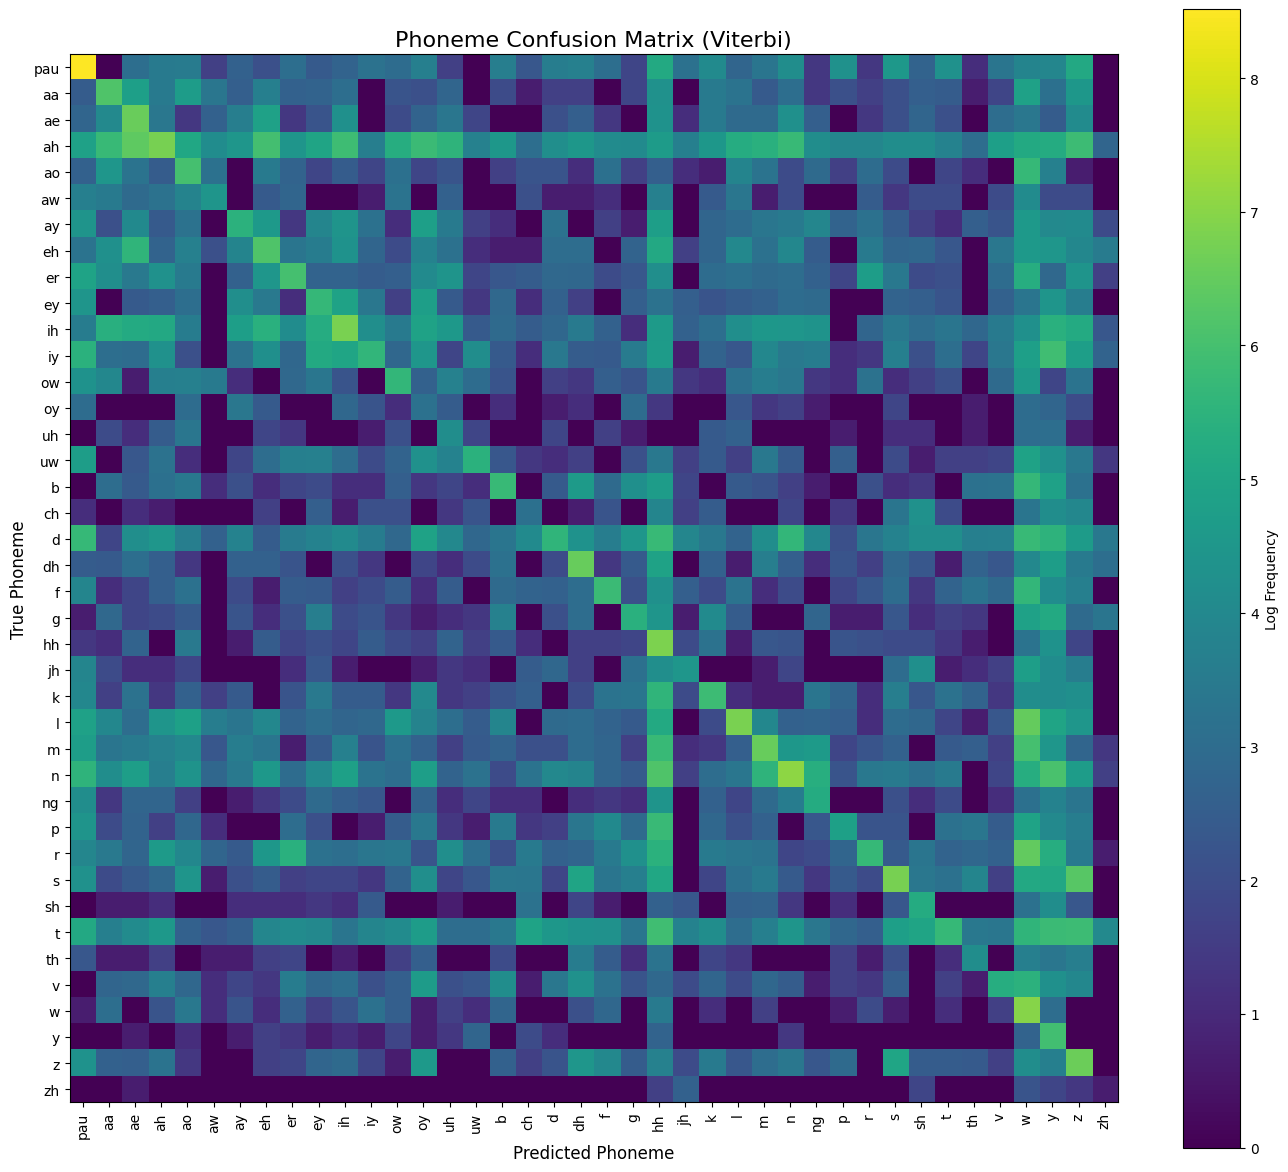

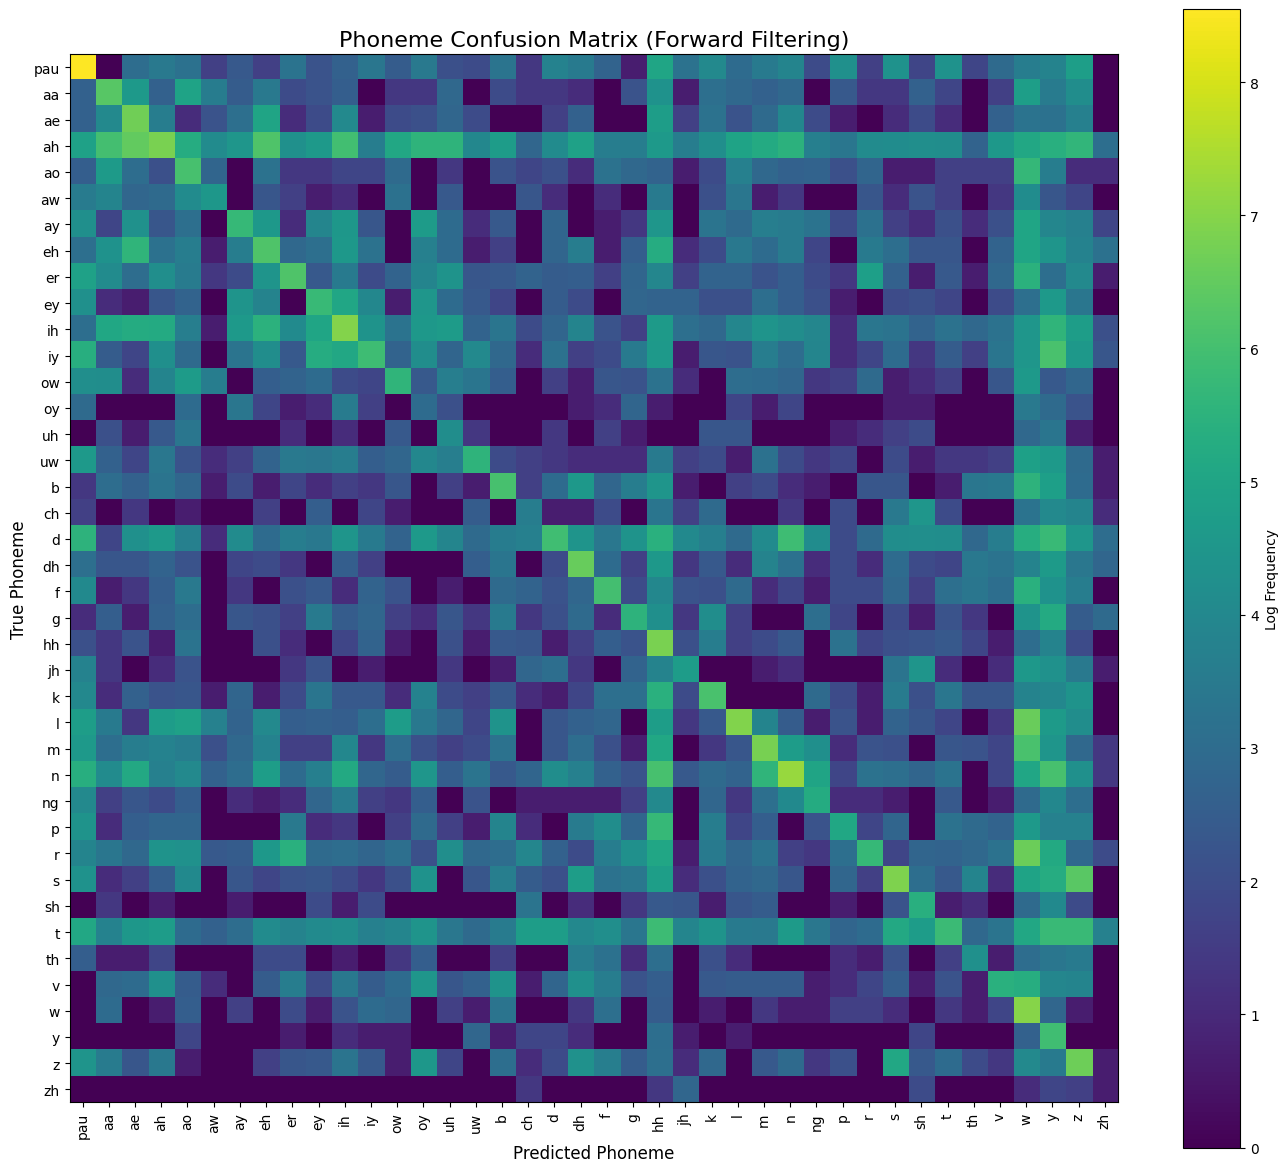

In [10]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(conf_matrix, title):
    plt.figure(figsize=(14, 12)) # Made slightly larger to fit all labels
    plt.imshow(np.log(conf_matrix + 1), cmap='viridis')
    plt.colorbar(label='Log Frequency')
    plt.title(title, fontsize=16)
    plt.xlabel('Predicted Phoneme', fontsize=12)
    plt.ylabel('True Phoneme', fontsize=12)

    # Plot ALL phonemes (step=1) and rotate 90 degrees to prevent overlapping text
    plt.xticks(np.arange(K), PHONEMES, rotation=90)
    plt.yticks(np.arange(K), PHONEMES)

    plt.tight_layout()
    plt.show()

# Plot Viterbi
plot_confusion_matrix(conf_mat_v, 'Phoneme Confusion Matrix (Viterbi)')

# Plot Forward (Filtering)
plot_confusion_matrix(conf_mat_f, 'Phoneme Confusion Matrix (Forward Filtering)')

6.5 - Analysis and Discussion

1. How does the accuracy differ between Forward Filtering and Viterbi, and why?

The Forward Filtering algorithm consistently achieved higher accuracy than the Viterbi Decoding algorithm. On the test set, Filtering achieved an accuracy of 33.84%, while Viterbi only got 30.54%. This difference is due to the mathematical designs of each algorithm. Filtering computes the marginal probability of a single state at a specific time step, which means it is deciding the most likely phoneme frame-by-frame. This approach minimizes the frame error rate. On the other hand, Viterby computes the most likely joint sequence of states. It optimizes for th best overall "path" and purposefully selects a locally suboptimal phoneme for a specific frame if it results in a sequence with higher transition probabilities. Because the evaluation metric strictly counts individual correct frames, Filtering scores better.

2. Is the accuracy different between the train and test set? Why?

Yes, the model performs slightly better on the training set than on the testing set. For the Filtering algorithm, training accuracy was 35.82%, while the test accuracy dropped to 33.84%. Likewise, the Viterbi algorithm dropped from 32.47% to 30.54%. This slight degradation is an indication of mild overfitting in the model. The model's emission parameters were estimated from the utterances in the training set, which means the Gaussian distributions slightly memorized the specific details of the audio files. When the model evaluates the test data, the new acoustic features do not perfectly line up with the training files, so there is a slight drop in performance. Since the decrease is minor, the overfitting is not a dominant feature in the training set's performance.

3. Which phonemes are most often confused? 

Based off the bright clusters of squares away from the diagonal of the matrices, the model has a few groups of phonemes that are frequently confused.

First, vowels with similar sounds are often confused by the model. For example, 'aa' is mistaken for 'ao' and 'ah', while 'ih' has overlap with 'iy' and 'eh'.

Next, 'm', 'n', and 'ng' have significant cross-confusion, likely because they have similar nasal sounds.

Next, the model frequently mistakes quieter phonemes, such as 'f', 'th', and 'hh' as 'pau'. The low volume of these phonemes makes them difficult for the model to distiguish from ambient noise.

Finally, pairs that have the same mouth position but slightly different sounds, like 's' and 'z', show noticable overlap. This indicates that the model sometimes fails to detect voicing.

4. For which phonemes is the model better/worse at predicting them correctly?

The model is excellent at predicting 'pau' (silence), representeed by the bright yellow square at the top left corner of the matrix. Silence has a lack of energy that forms a tight cluster. The model is also very accurate for distinct phonemes such as 's', 'l', and 'n'; as well as extreme vowels like 'iy' and 'ah'

The model performs very poorly on 'zh', 'oy', 'uh', 'ch', and 'jh', which are all quite dark on their diagonal position. This is because these phonemes are either relatively rare in the dataset, such as 'zh', or are dynamic in how they are sounded out, such as 'ch'. The dynamic phonemes are difficult to capture with a single Gaussian curve.

5. Generally, how well does the approach work?

The approach works well, with close to the expected accuracy percentages and most phonemes have a brighter diagonal than horizontal which means that they are correctly predicted more often than not, aside from the few that are especially poor.

However, the approach of the model is limited by its architecture. The model struggles to capture the high variance of human pronunciation with only a single multivariate Gaussian and hidden state. Furthermore, relying solely on acoustic features and transition probabilities without a robust language model to back it up means that the system frequently predicts sequences that are verbally plausible but linguistically impossible.